# Stock Market Price Prediction using Time Series Models

This Python function is an easy-to-use tool for analyzing and forecasting stock prices using historical data, technical indicators, and multiple time series models.

## Function Features

- **Data Retrieval:** Pulls historical stock price data and 10-Year Treasury yields using the `yfinance` module.
- **Technical Indicators:** Computes Bollinger Bands, RSI, and a simple moving average.
- **Visualization:** Plots price data with and without technical indicators, candlestick charts, and outlier analysis for returns and trading volume.
- **Forecasting Models Used:**
  - **ARIMA:** Autoregressive Integrated Moving Average
  - **LSTM:** Long Short-Term Memory Neural Network
  - **Prophet:** Facebook’s time series forecasting model
- **Model Evaluation:** Computes RMSE (root mean squared error) for each model.
- **Prediction:** Estimates next closing price and percent change using each model.

## Simple Usage

The function requires no knowledge or time series models to use.
Call the function using **stock_analysis()**.
The following variables are used in the function call:
- **ticker:** the NYSE ticker you want to analyze.
- **start:** the starting point of the data you want to pull, in YYYY-MM-DD format
    - the default value is '2020-01-01'
- **end:** the ending point of the data you want to pull, in YYYY-MM-DD format
    - the default value is your system's current date
- **ma_window:** the period you want to use to calculate moving average
    - the default value is 20
    - typical values are 20, 50, and 200
    - this will also effect Bollinger Bands
- **rsi_window:** the period you want to use to calculate RSI
    - the default value is 14, which is typical
- **stock_preview:** choose whether or not you want preliminary visualizations to be shown
    - the default value is True
    - setting to False will jump straight to modeling and predictions

#### Install any modules needed

In [ ]:
!pip install yfinance --quiet
!pip install mplfinance --quiet
!pip install statsmodels --quiet
!pip install scikit-learn --quiet
!pip install tensorflow --quiet --user
!pip install prophet --quiet

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


#### The following modules and submodules are necesary to use this function:

In [ ]:
import numpy as np
import yfinance as yf
import mplfinance as mpf
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
import pandas as pd
import warnings
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from prophet import Prophet
import logging
from datetime import date

#### Define the stock_analysis function

In [ ]:
def stock_analysis(ticker, start='2020-01-01', end= date.today(), ma_window = 20, rsi_window = 14, stock_preview = True):
    warnings.filterwarnings("ignore")

    # download stock and bond data from yahoo finance, clean data
    data = yf.download(ticker, start=start, end=end, auto_adjust=True)
    bonds = yf.download("^TNX", start=start, end=end)

    data.columns = ['Close', 'High', 'Low', 'Open', 'Volume']
    bonds = bonds.rename(columns={'Close': '10Y_Yield'})

    # only keep the 10Y yield column to merge
    bonds = bonds[['10Y_Yield']]

    # align frequencies with forward fill to match stock market days
    bonds = bonds.reindex(data.index, method='ffill')
    bonds.columns = [col for col in bonds.columns]

    # checking if data was found successfully
    if data.empty:
        raise ValueError(f"\nNo data returned for ticker '{ticker}'.")
    if len(data) < 100:
        raise ValueError(f"\nNot enough data for analysis, pick a larger interval")
    else:
        print(f"\n{ticker} data from {start} to {end} collected successfully")

    # dataframe information and summary statistics
    if stock_preview:
        print(f"\nNumber of data points collected: {len(data)}")
        print(f"\nSummary Statistics of {ticker} data")
        print(data.describe(),f"\n")

    #  Closing Price over Time
    if stock_preview:
        print("The following graph will display the selected stock's closing price over the entire time period.")
        plt.figure(figsize=(12, 6))
        plt.plot(data.index, data['Close'], color='darkblue')
        plt.title(f'{ticker} Closing Price Over Time \n({start} to {end})', fontsize=16)
        plt.xlabel('Date', fontsize=12)
        plt.ylabel('Price (USD)', fontsize=12)
        plt.grid(True)
        plt.show()

    # Moving Averages & Technical Indicator calculations
    data['MA'] = data['Close'].rolling(window=ma_window).mean()
    data['STD'] = data['Close'].rolling(window=ma_window).std()

    # Calculate the upper and lower Bollinger Bands
    data['Upper Band'] = data['MA'] + (data['STD'] * 2)
    data['Lower Band'] = data['MA'] - (data['STD'] * 2)

    # RSI CALCULATION
    data['delta'] = data['Close'].diff()
    data['gain'] = (data['delta'].where(data['delta'] > 0, 0)).rolling(window=rsi_window).mean()
    data['loss'] = (-data['delta'].where(data['delta'] < 0, 0)).rolling(window=rsi_window).mean()
    data['rs'] = data['gain'] / data['loss']
    data['rsi'] = 100 - (100 / (1 + data['rs']))

    print(f'\n\n\nThis graph shows the stock closing price over time, along with the moving average (period chosen with ma_period variable),')
    print(f'    upper and lower Bollinger Bands (moving average plus/minus 2*standard deviation of closing price), and the Relative Strength')
    print(f'    Index (RSI). An RSI of 70 or more typically means the stock is being over bought. A value of 30 or less typically means the')
    print(f'    stock is being over-sold\n')

    # Plot the closing price, moving average, and Bollinger Bands
    fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(12, 6), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
    ax1.plot(data.index, data['Close'], color='darkblue', label='Closing Price')
    ax1.plot(data.index, data['MA'], color='orange', label=f'{ma_window}-day Moving Average')
    ax1.plot(data.index, data['Upper Band'], color='green', linestyle='--', label='Upper Band')
    ax1.plot(data.index, data['Lower Band'], color='red', linestyle='--', label='Lower Band')
    ax1.fill_between(data.index, data['Lower Band'], data['Upper Band'], color='gray', alpha=0.3)
    ax1.set_title(f'{ticker} Price with Indicators\n({start} to {end})', fontsize=16)
    ax1.set_ylabel('Price (USD)', fontsize=12)
    ax1.grid(True)
    ax1.legend(loc='best', fontsize = 8)

    #plot rsi below
    ax2.plot(data.index, data['rsi'], color='purple', alpha=0.7)
    ax2.axhline(30, color='red', linestyle='--', alpha=0.7)
    ax2.axhline(70, color='green', linestyle='--', alpha=0.7)
    ax2.set_xlabel('Date', fontsize=12)
    ax2.set_ylabel('RSI', fontsize=12)
    ax2.grid(True)
    plt.tight_layout()
    plt.show()

    # Stock Volatility Analysis (Candlestick Chart)
    if stock_preview:
        print(f'\n\n\nCandlestick charts are great for understanding how a stock moves throughout the day. If the candlestick is green, the closing')
        print(f'    price was greater than the opening price (positive returns). If the candlestick is red, the stock had negative returns for')
        print(f'    that day. The high and low prices for the day is represented by the "tips" of the candlestick. Candlestick charts also display')
        print(f'    total trading volume for each day at the bottom of the chart.\n')

        mpf.plot(data,
                 type='candle',
                 style='yahoo',
                 volume=True,
                 warn_too_much_data= len(data) + 1,
                 title = f"{ticker} Candlestick Chart \n({start} to {end})",
                 figsize = (12,6))

    # Outlier Detection with Box Plot, Detecting Anomalies in Stock Prices
    # calculate daily returns
    data['Returns'] = data['Close'].pct_change().dropna()

    if stock_preview:
        print(f"\n\n\nThis is a graph that shows the stock's daily returns (calculated by the percentage change from one period to the next). Large")
        print(f'    spikes in the chart represent days with high market volatility. \n')

        plt.figure(figsize=(12, 6))
        plt.plot(data.index, data['Returns'], color='darkblue', alpha=0.7)
        plt.title(f'{ticker} Daily Returns \n({start} to {end})', fontsize=16)
        plt.xlabel('Date', fontsize=12)
        plt.ylabel('Returns', fontsize=12)
        plt.grid(True)
        plt.show()

        print(f'\n\n\nThis graph displays the same daily return data, this time pointing out specific days where there were outliers. The line in the')
        print(f'    middle of the box is the average return. The box itself represents the interquartile range (IQR). Any points outside the extremes')
        print(f'    of the boxplot are considered outliers\n')
        plt.figure(figsize=(12, 6))
        plt.boxplot(x = data['Returns'].dropna(),
                    vert=False,
                    patch_artist=True,
                    boxprops=dict(facecolor='skyblue'),
                    medianprops=dict(color='red'))
        plt.title(f'Boxplot of {ticker} Daily Returns')
        plt.ylabel('Returns', fontsize=12)
        plt.grid(True)
        plt.show()

        Q1 = data['Returns'].quantile(0.25)
        Q3 = data['Returns'].quantile(0.75)
        IQR = Q3 - Q1

        # Define outlier bounds
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Filter outliers
        lower_outliers = data[(data['Returns'] < lower_bound)]
        upper_outliers = data[(data['Returns'] > upper_bound)]

        top_high_outliers = data.sort_values(by="Returns", ascending=False).head(5)
        top_low_outliers = data.sort_values(by="Returns", ascending=True).head(5)
        # Print outlier dates and values
        print(f'\n{ticker} has {len(upper_outliers)} high outliers in daily returns. The top 5 are\n')
        print(top_high_outliers[['Returns']])
        print(f'\n{ticker} has {len(upper_outliers)} low outliers in daily returns. The top 5 are\n')
        print(top_low_outliers[['Returns']])

        #Find outliers in trading volume
        print(f'\n\n\nThe boxplot for trading volume shows the outliers in trading volume, similar to how the boxplot for returns showed outliers in returns\n')
        plt.figure(figsize=(12,6))
        plt.boxplot(x = data['Volume'].dropna(),
                    vert=False,
                    patch_artist=True,
                    boxprops=dict(facecolor='skyblue'),
                    medianprops=dict(color='red'))
        plt.title(f'Boxplot of {ticker} Trading Volume')
        plt.ylabel('Volume', fontsize=12)
        plt.grid(True)
        plt.show()

        Q1 = data['Volume'].quantile(0.25)
        Q3 = data['Volume'].quantile(0.75)
        IQR = Q3 - Q1

        # Define outlier bounds
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        lower_outliers = data[data['Volume'] < lower_bound]
        upper_outliers = data[data['Volume'] > upper_bound]

        top_spikes = data.sort_values(by='Volume', ascending=False).head(5)
        # Print outlier dates and values
        print(f'\n{ticker} has {len(upper_outliers)} volume spikes. The top 5 spikes are:\n')
        print(top_spikes[['Volume']])

    # Merge stock data and bond yields on date
    merged_data = data.copy()
    merged_data = merged_data.merge(bonds, left_index=True, right_index=True)
    merged_data.columns = merged_data.columns[:-1].tolist() + ['bond_yield']
    merged_data.index = pd.to_datetime(merged_data.index)  # Ensure it's a datetime index
    merged_data = merged_data.asfreq('D', method='pad')

    # remove observations with missing MA and RSI values
    model_data = merged_data.dropna(subset=['MA', 'rsi'])

    y = model_data['Close']  # Dependent variable: Stock Price (Close)
    X = model_data[['MA', 'bond_yield', 'rsi']]  # Exogenous variables: Moving Average, Yield, RSI

    # create training (first 80%) and testing (last 20%)
    split_index = int(len(model_data) * 0.8)

    X_train = X.iloc[:split_index]
    X_test = X.iloc[split_index:]

    y_train = y.iloc[:split_index]
    y_test = y.iloc[split_index:]

    # ARIMA MODEL
    print(f"\n\n\nTraining ARIMA Model...(Model 1/3)")

    # grid search to minimize AIC
    results = []
    for p in range(3):  # p = 0, 1, 2
        for d in range(2):  # d = 0, 1
            for q in range(3):  # q = 0, 1, 2
                try:
                    arima_model = ARIMA(y_train, exog = X_train, order=(p, d, q))
                    fitted_model = arima_model.fit()
                    results.append((p, d, q, fitted_model.aic, fitted_model.bic))
                except Exception as e:
                    print(f"Error with parameters p={p}, d={d}, q={q}: {e}")
                    continue

    # Convert results into DataFrame and find the best model
    results_df = pd.DataFrame(results, columns=["p", "d", "q", "AIC", "BIC"])
    best_model = results_df.sort_values("AIC").iloc[0]

    # Fit final model with best parameters
    final_model = ARIMA(y_test, exog=X_test, order=(best_model['p'], best_model['d'], best_model['q']))
    fitted_final_model = final_model.fit()

    forecast_index = X_test.index

    # Generate forecasts
    forecast_values = fitted_model.forecast(steps=len(X_test), exog=X_test)

    # Set the correct index on the result
    forecast_values.index = forecast_index

    # plot the arima results
    plt.figure(figsize=(12, 6))
    plt.plot(y_test, label='Actual', color='blue')
    plt.plot(y_test.index, forecast_values, label='Forecast', color='orange', linestyle='--')
    plt.title(f"{ticker} Price Forecast (ARIMA)")
    plt.xlabel("Date")
    plt.ylabel("Price (USD)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    #find last observations
    last_obs = X_test.iloc[-1]
    last_close = y_test.iloc[-1]
    ma = last_obs['MA']
    tbill = last_obs['bond_yield']
    rsi = last_obs['rsi']

    # Build the DataFrame for prediction
    predict_values = pd.DataFrame([[ma, tbill, rsi]], columns=['MA', 'bond_yield', 'rsi'])

    # Forecast 1 step ahead
    arima_prediction = fitted_final_model.forecast(steps=1, exog=predict_values)
    arima_pct_change = ((arima_prediction.iloc[0] - last_close) / last_close) * 100
    arima_direction = "+" if arima_pct_change > 0 else ""
    print(f"\nARIMA predicted price for next day: {arima_prediction.iloc[0]:.2f} ({arima_direction}{arima_pct_change:.2f}%)")

    # find rmse
    arima_mae = mean_absolute_error(y_test, forecast_values)
    arima_mse = mean_squared_error(y_test, forecast_values)
    arima_mape = np.mean(np.abs((y_test - forecast_values) / y_test)) * 100
    arima_rmse = np.sqrt(arima_mse)

    print(f"    MAE: {arima_mae:.4f}")
    print(f"    RMSE: {arima_rmse:.4f}")
    print(f"    MAPE: {arima_mape:.4f}")


    ##LSTM MODEL
    lstm_data = model_data[['Close', 'MA', 'bond_yield', 'rsi']]

    # normalize the data
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(lstm_data)

    # create sequences (training the neural network)
    def create_sequences(data, seq_length):
        X, y = [], []
        for i in range(seq_length, len(data)):
            X.append(data[i-seq_length:i])
            y.append(data[i, 0])  # Predicting 'Close'
        return np.array(X), np.array(y)

    sequence_length = 60
    lstm_X, lstm_y = create_sequences(scaled_data, sequence_length)

    # Train/test split
    lstm_X_train, lstm_X_test = lstm_X[:split_index], lstm_X[split_index:]
    lstm_y_train, lstm_y_test = lstm_y[:split_index], lstm_y[split_index:]

    # train the model
    model = Sequential()
    model.add(LSTM(units=64, return_sequences=True, input_shape=(lstm_X_train.shape[1], lstm_X_train.shape[2])))
    model.add(LSTM(units=64))
    model.add(Dense(1))

    print(f"\n\n\nTraining LSTM Model...(Model 2/3)")
    model.compile(optimizer='adam', loss='mean_squared_error')
    model.fit(lstm_X_train, lstm_y_train, epochs=20, batch_size=32, validation_data=(lstm_X_test, lstm_y_test), verbose=0)

    # create predictions
    lstm_predictions = model.predict(lstm_X_test)

    dummy_features = lstm_X_test[:, -1, 1:]
    predicted_prices = scaler.inverse_transform(np.concatenate((lstm_predictions, dummy_features), axis=1))[:, 0]
    real_prices = scaler.inverse_transform(np.concatenate((lstm_y_test.reshape(-1, 1), dummy_features), axis=1))[:, 0]

    # plot LSTM
    plt.figure(figsize=(12, 6))
    plt.plot(real_prices, label='Actual', color='blue')
    plt.plot(predicted_prices, label='Forecast', color='orange', linestyle='--')
    plt.title(f"{ticker} Price Forecast (LSTM)")
    plt.xlabel("Periods")
    plt.ylabel("Price (USD)")
    plt.legend()
    plt.show()

    # find forecast for next period
    n_features = scaled_data.shape[1]
    last_sequence = scaled_data[-sequence_length:]
    last_sequence = last_sequence.reshape((1, sequence_length, n_features))
    predicted_next = model.predict(last_sequence, verbose=0)

    reconstructed_input = np.copy(last_sequence[:, -1, :])
    reconstructed_input[0, 0] = predicted_next

    lstm_predicted_price = scaler.inverse_transform(reconstructed_input)[0, 0]

    lstm_pct_change = ((lstm_predicted_price - last_close) / last_close) * 100
    lstm_direction = "+" if lstm_pct_change > 0 else ""
    print(f"\nLSTM predicted price for next day: {lstm_predicted_price:.2f} ({lstm_direction}{lstm_pct_change:.2f}%)")

    lstm_mae = mean_absolute_error(real_prices, predicted_prices)
    lstm_mse = mean_squared_error(real_prices, predicted_prices)
    lstm_mape = np.mean(np.abs((real_prices - predicted_prices) / real_prices)) * 100
    lstm_rmse = np.sqrt(lstm_mse)

    print(f"    MAE: {lstm_mae:.4f}")
    print(f"    RMSE: {lstm_rmse:.4f}")
    print(f"    MAPE: {lstm_mape:.4f}")

    ##PROPHET MODEL
    print(f"\n\n\nTraining Prophet Model...(Model 3/3)")

    logging.getLogger("cmdstanpy").setLevel(logging.CRITICAL + 1)

    # clean data, prophet requires date to be called ds, outcome variable called y
    model_data.reset_index(inplace=True)
    prophet_data = model_data[['Date', 'Close', 'MA', 'bond_yield', 'rsi']]

    prophet_train = prophet_data[:split_index]
    prophet_test = prophet_data[split_index:]

    prophet_train = prophet_train[['Date', 'Close', 'MA', 'bond_yield', 'rsi']]
    prophet_train.columns = ['ds', 'y', 'MA', 'bond_yield', 'RSI']

    prophet_test = prophet_test[['Date', 'Close', 'MA', 'bond_yield', 'rsi']]
    prophet_test.columns = ['ds', 'y', 'MA', 'bond_yield', 'RSI']

    # call in model and add exongenous variables
    prophet = Prophet()

    prophet.add_regressor('MA')
    prophet.add_regressor('bond_yield')
    prophet.add_regressor('RSI')

    # fit the model
    prophet.fit(prophet_train)

    # forecast the next period
    prophet_next = prophet_test[['ds', 'MA', 'bond_yield', 'RSI']].iloc[[-1]]
    prophet_forecast = prophet.predict(prophet_next)

    predicted_price = prophet_forecast['yhat'].values[0]
    predicted_date = prophet_forecast['ds'].values[0]

    forecast = prophet.predict(prophet_test[['ds', 'MA', 'bond_yield', 'RSI']])

    # plot prophet model predictions
    plt.figure(figsize=(12, 6))
    plt.plot(prophet_test['ds'], prophet_test['y'], label='Actual', color='blue')
    plt.plot(forecast['ds'], forecast['yhat'], label='Predicted', color='orange', linestyle='--')
    plt.title(f'{ticker} Price Forecast (Prophet)')
    plt.xlabel("Date")
    plt.ylabel("Price (USD)")
    plt.legend()
    plt.show()

    proph_pct_change = ((predicted_price - last_close) / last_close) * 100
    proph_direction = "+" if proph_pct_change > 0 else ""
    print(f"\nProphet predicted price for next day: {predicted_price:.2f} ({proph_direction}{proph_pct_change:.2f}%)")

     # find prophet error metrics
    prophet_mae = mean_absolute_error(prophet_test['y'], forecast['yhat'])
    prophet_mse = mean_squared_error(prophet_test['y'], forecast['yhat'])
    prophet_mape = np.mean(np.abs((prophet_test['y'] - forecast['yhat']) / prophet_test['y'])) * 100
    prophet_rmse = np.sqrt(prophet_mse)

    print(f"    MAE: {prophet_mae:.4f}")
    print(f"    RMSE: {prophet_rmse:.4f}")
    print(f"    MAPE: {prophet_mape:.4f}")

    print(f"\n\n\nModel Summaries:")
    print(f"ARIMA MAE: {arima_mae:.4f}, RMSE: {arima_rmse:.4f}, MAPE: {arima_mape:.4f}, predicted price of {arima_prediction.iloc[0]:.2f} ({arima_direction}{arima_pct_change:.2f}%)")
    print(f"LSTM MAE: {lstm_mae:.4f}, RMSE: {lstm_rmse:.4f}, MAPE: {lstm_mape:.4f}, predicted price of {lstm_predicted_price:.2f} ({lstm_direction}{lstm_pct_change:.2f}%)")
    print(f"Prophet MAE: {prophet_mae:.4f}, RMSE: {prophet_rmse:.4f}, MAPE: {prophet_mape:.4f}, predicted price of {predicted_price:.2f} ({proph_direction}{proph_pct_change:.2f}%)")

#### Call the function for Procter and Gamble (PG) using default values

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed



PG data from 2020-01-01 to 2025-04-23 collected successfully

Number of data points collected: 1333

Summary Statistics of PG data
             Close         High          Low         Open        Volume
count  1333.000000  1333.000000  1333.000000  1333.000000  1.333000e+03
mean    137.530241   138.596261   136.433401   137.468867  7.266541e+06
std      19.040086    19.016086    19.015338    19.049711  3.001213e+06
min      85.807831    91.121420    82.856814    87.994750  2.132500e+06
25%     123.480080   124.437633   122.657281   123.483607  5.518800e+06
50%     137.517868   138.488826   136.103623   137.135320  6.541400e+06
75%     149.405045   150.969063   148.524569   149.368377  8.165200e+06
max     177.504425   178.875026   176.546287   177.800774  3.309570e+07 

The following graph will display the selected stock's closing price over the entire time period.


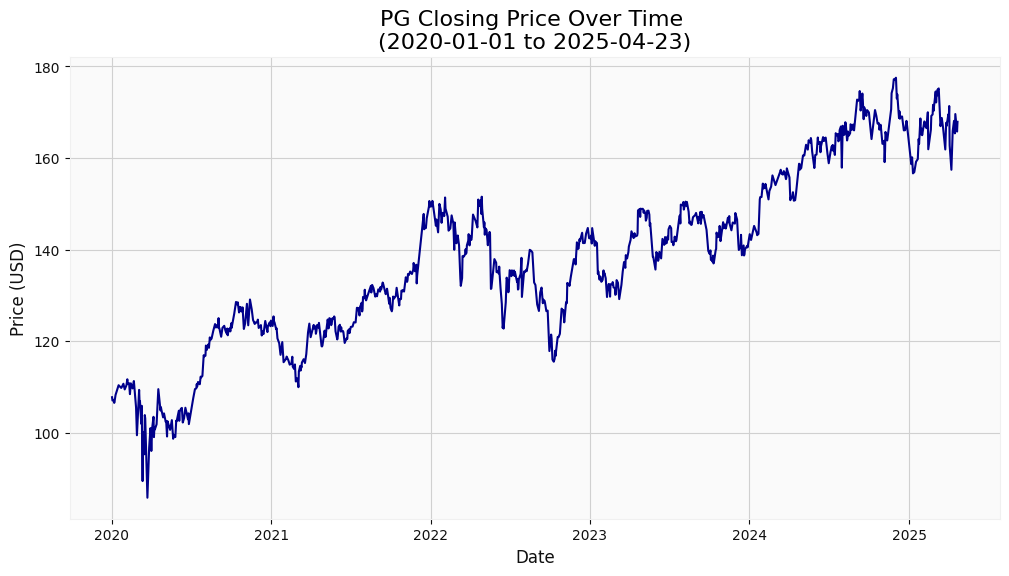




This graph shows the stock closing price over time, along with the moving average (period chosen with ma_period variable),
    upper and lower Bollinger Bands (moving average plus/minus 2*standard deviation of closing price), and the Relative Strength
    Index (RSI). An RSI of 70 or more typically means the stock is being over bought. A value of 30 or less typically means the
    stock is being over-sold



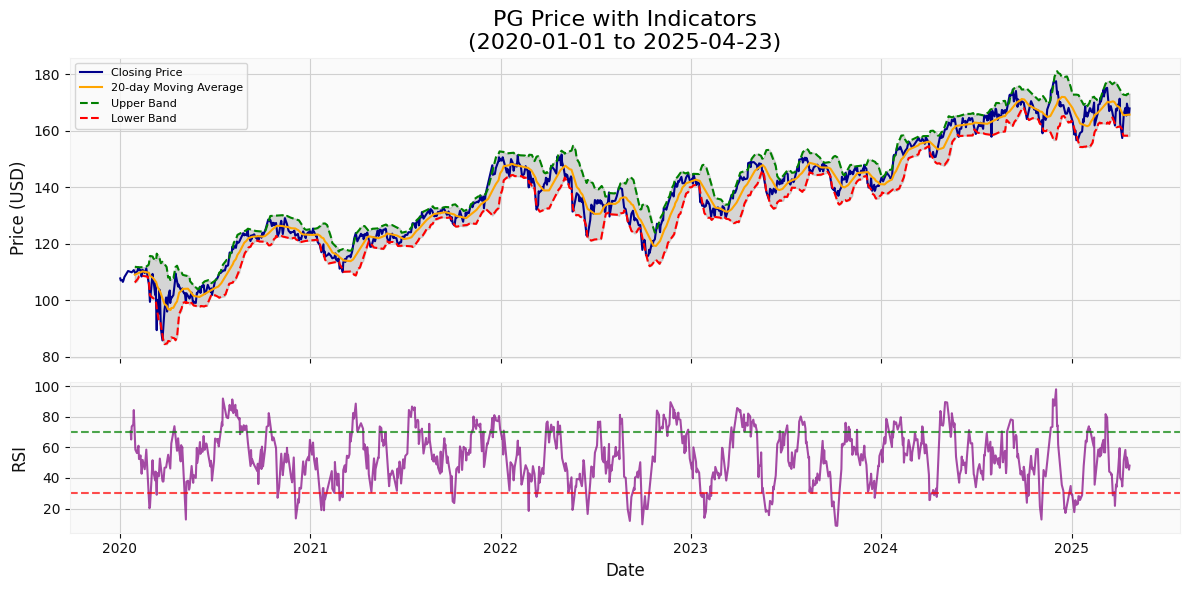




Candlestick charts are great for understanding how a stock moves throughout the day. If the candlestick is green, the closing
    price was greater than the opening price (positive returns). If the candlestick is red, the stock had negative returns for
    that day. The high and low prices for the day is represented by the "tips" of the candlestick. Candlestick charts also display
    total trading volume for each day at the bottom of the chart.



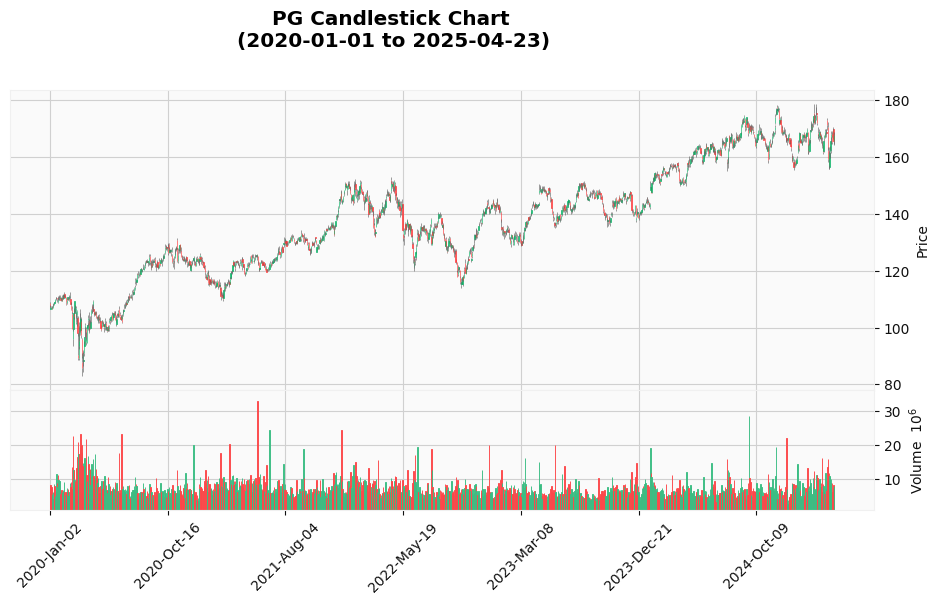




This is a graph that shows the stock's daily returns (calculated by the percentage change from one period to the next). Large
    spikes in the chart represent days with high market volatility. 



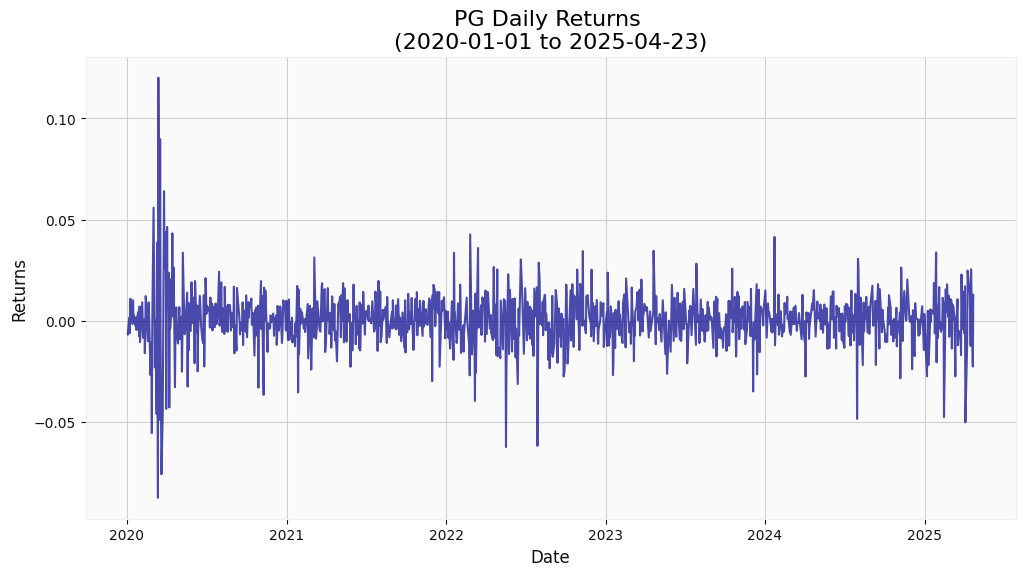




This graph displays the same daily return data, this time pointing out specific days where there were outliers. The line in the
    middle of the box is the average return. The box itself represents the interquartile range (IQR). Any points outside the extremes
    of the boxplot are considered outliers



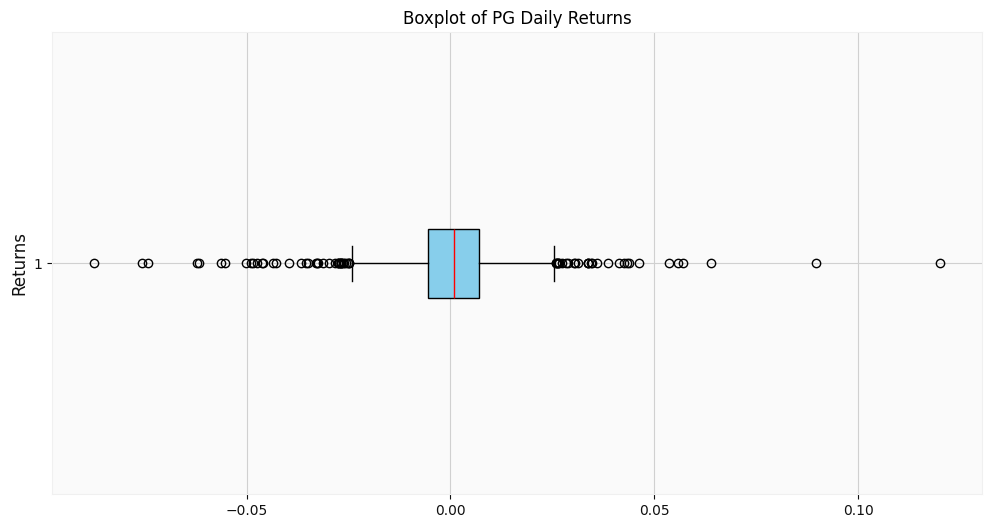


PG has 30 high outliers in daily returns. The top 5 are

             Returns
Date                
2020-03-13  0.120091
2020-03-17  0.089770
2020-03-26  0.064011
2020-03-24  0.057011
2020-03-02  0.055904

PG has 30 low outliers in daily returns. The top 5 are

             Returns
Date                
2020-03-12 -0.087374
2020-03-20 -0.075792
2020-03-11 -0.074326
2022-05-18 -0.062322
2022-07-29 -0.061799



The boxplot for trading volume shows the outliers in trading volume, similar to how the boxplot for returns showed outliers in returns



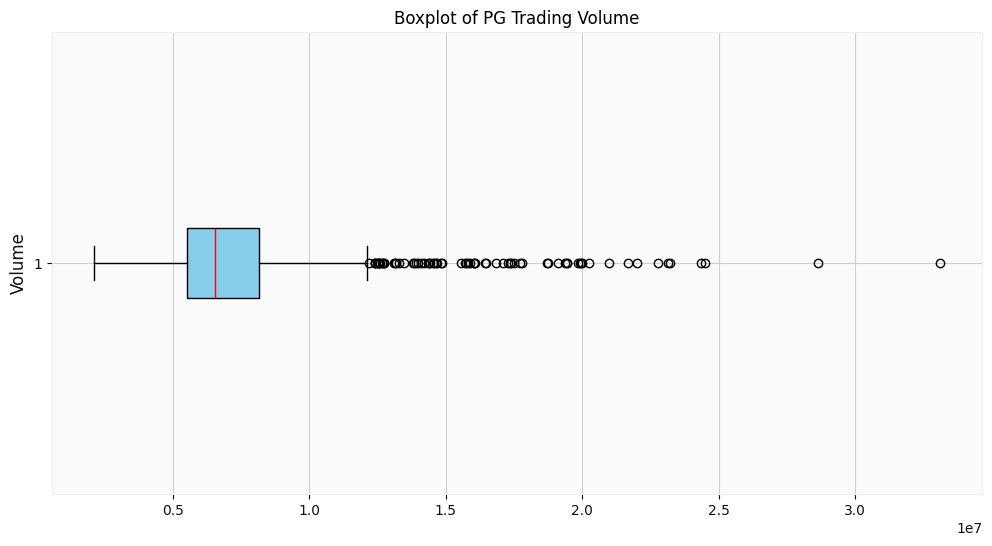


PG has 72 volume spikes. The top 5 spikes are:

              Volume
Date                
2021-05-27  33095700
2024-09-20  28647500
2021-06-25  24504900
2021-12-17  24349400
2020-06-26  23201700



Training ARIMA Model...(Model 1/3)


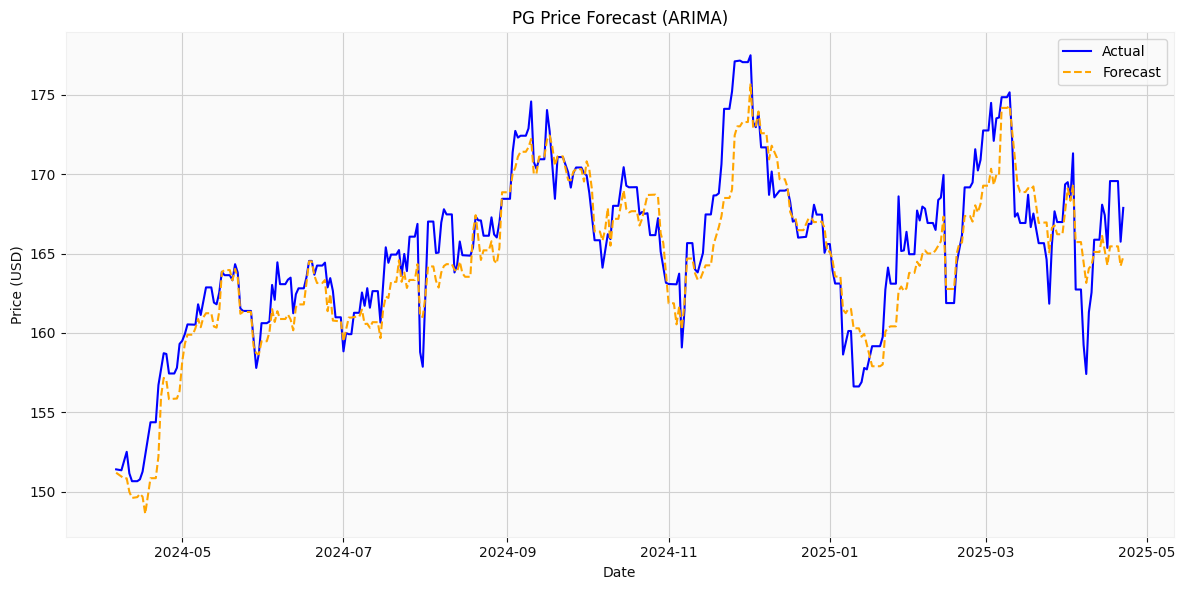


ARIMA predicted price for next day: 167.49 (-0.23%)
    MAE: 1.5743
    RMSE: 1.9904
    MAPE: 0.9506



Training LSTM Model...(Model 2/3)
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step 


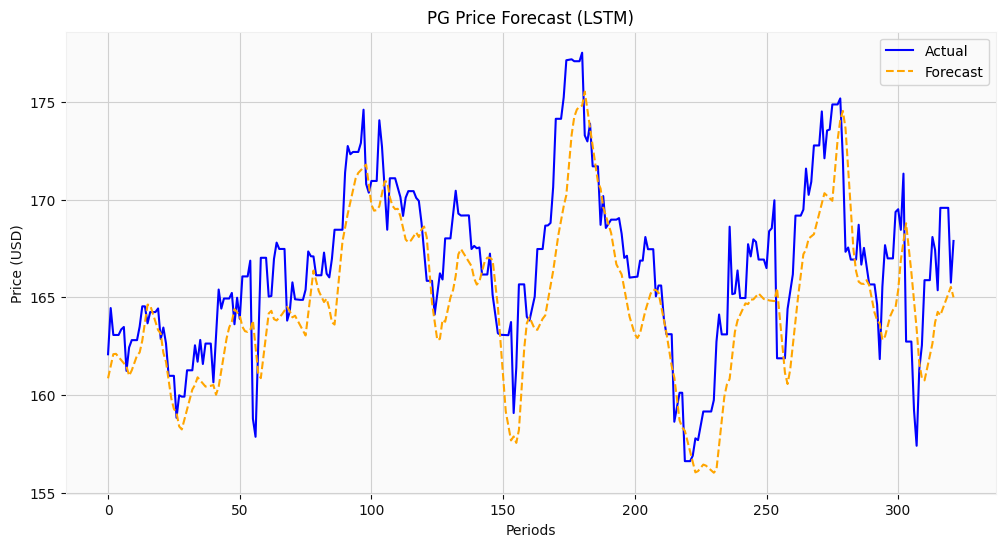


LSTM predicted price for next day: 164.71 (-1.89%)
    MAE: 2.3570
    RMSE: 2.8571
    MAPE: 1.4103



Training Prophet Model...(Model 3/3)


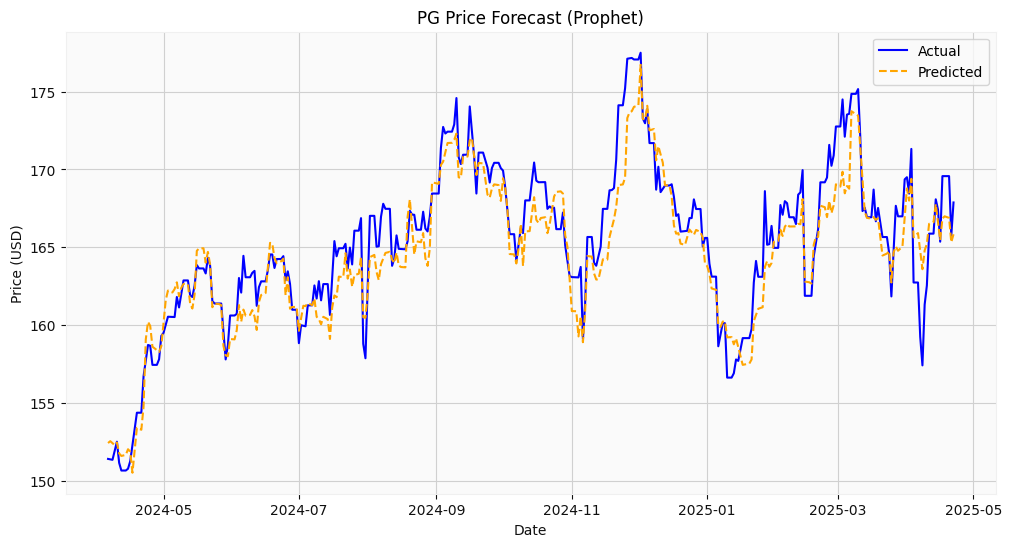


Prophet predicted price for next day: 165.83 (-1.22%)
    MAE: 1.4778
    RMSE: 1.8492
    MAPE: nan



Model Summaries:
ARIMA MAE: 1.5743, RMSE: 1.9904, MAPE: 0.9506, predicted price of 167.49 (-0.23%)
LSTM MAE: 2.3570, RMSE: 2.8571, MAPE: 1.4103, predicted price of 164.71 (-1.89%)
Prophet MAE: 1.4778, RMSE: 1.8492, MAPE: nan, predicted price of 165.83 (-1.22%)


In [ ]:
stock_analysis('PG')

#### Call the function for Apple (AAPL) with longer MA value

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed



AAPL data from 2020-01-01 to 2025-04-23 collected successfully

Number of data points collected: 1333

Summary Statistics of AAPL data
             Close         High          Low         Open        Volume
count  1333.000000  1333.000000  1333.000000  1333.000000  1.333000e+03
mean    156.265611   157.893485   154.461102   156.101746  8.886711e+07
std      44.360059    44.613424    44.032512    44.308474  5.265038e+07
min      54.449898    55.452163    51.595993    55.350239  2.323470e+07
25%     128.535522   129.886062   126.877762   128.554151  5.409170e+07
50%     154.293976   156.244326   151.944484   154.211246  7.482920e+07
75%     183.150406   184.658081   181.254160   182.821377  1.055686e+08
max     258.735504   259.814335   257.347047   257.906429  4.265100e+08 

The following graph will display the selected stock's closing price over the entire time period.


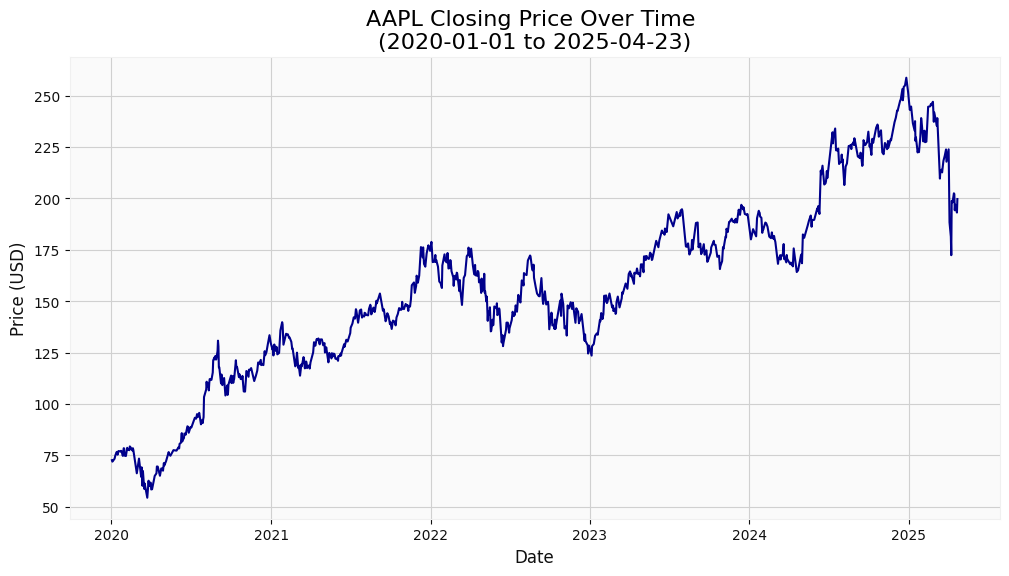




This graph shows the stock closing price over time, along with the moving average (period chosen with ma_period variable),
    upper and lower Bollinger Bands (moving average plus/minus 2*standard deviation of closing price), and the Relative Strength
    Index (RSI). An RSI of 70 or more typically means the stock is being over bought. A value of 30 or less typically means the
    stock is being over-sold



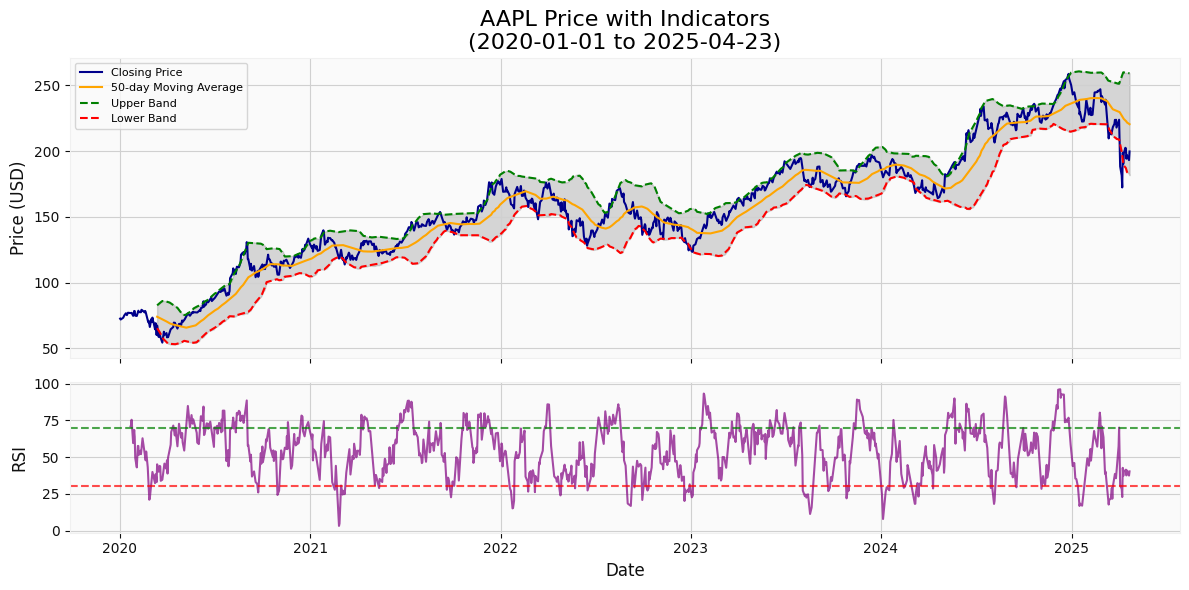




Candlestick charts are great for understanding how a stock moves throughout the day. If the candlestick is green, the closing
    price was greater than the opening price (positive returns). If the candlestick is red, the stock had negative returns for
    that day. The high and low prices for the day is represented by the "tips" of the candlestick. Candlestick charts also display
    total trading volume for each day at the bottom of the chart.



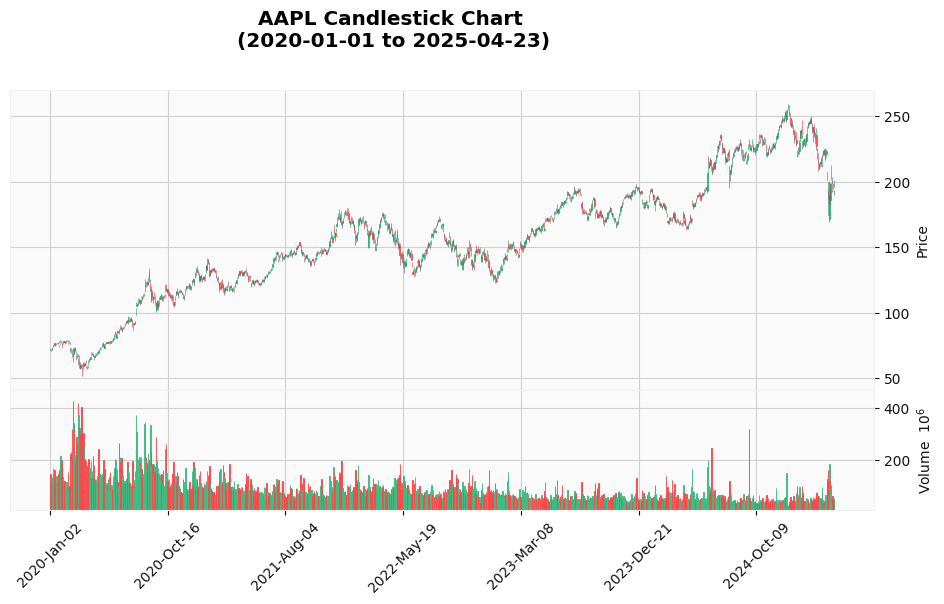




This is a graph that shows the stock's daily returns (calculated by the percentage change from one period to the next). Large
    spikes in the chart represent days with high market volatility. 



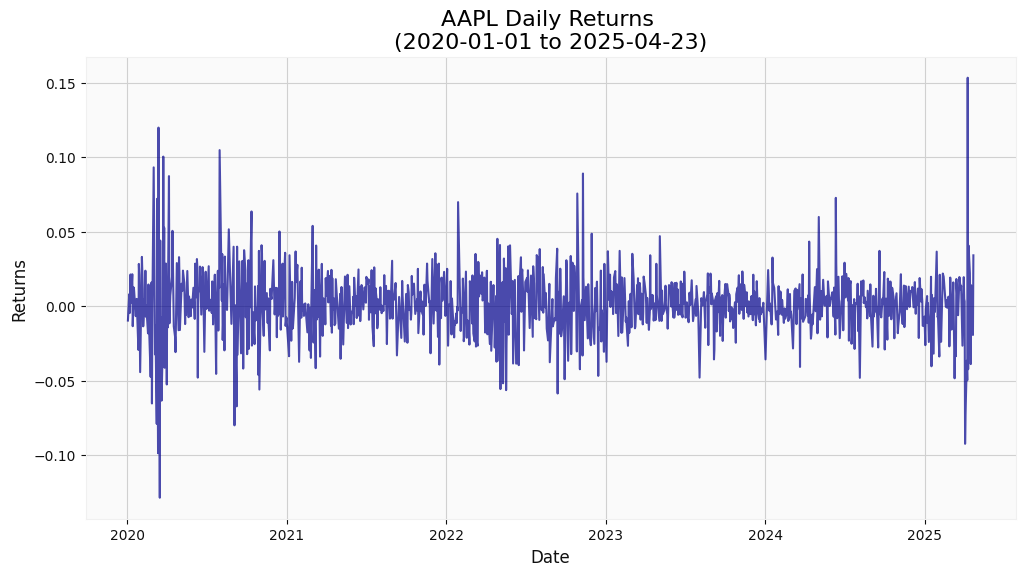




This graph displays the same daily return data, this time pointing out specific days where there were outliers. The line in the
    middle of the box is the average return. The box itself represents the interquartile range (IQR). Any points outside the extremes
    of the boxplot are considered outliers



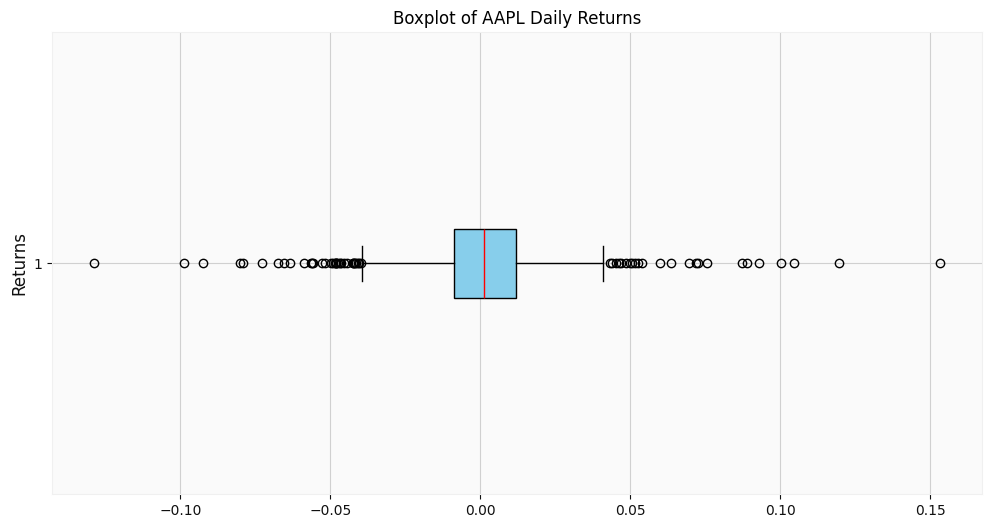


AAPL has 24 high outliers in daily returns. The top 5 are

             Returns
Date                
2025-04-09  0.153289
2020-03-13  0.119808
2020-07-31  0.104689
2020-03-24  0.100325
2020-03-02  0.093100

AAPL has 24 low outliers in daily returns. The top 5 are

             Returns
Date                
2020-03-16 -0.128647
2020-03-12 -0.098755
2025-04-03 -0.092456
2020-09-03 -0.080061
2020-03-09 -0.079092



The boxplot for trading volume shows the outliers in trading volume, similar to how the boxplot for returns showed outliers in returns



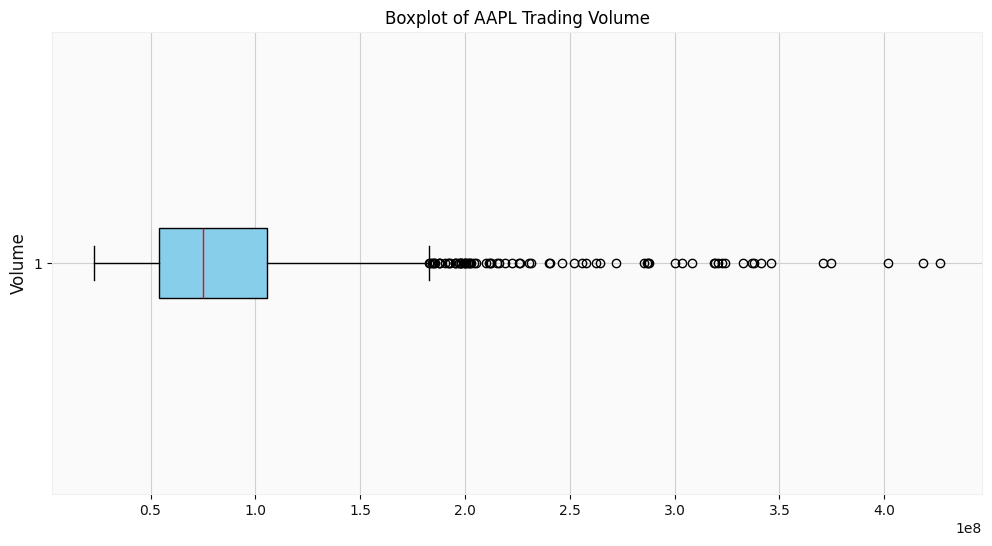


AAPL has 74 volume spikes. The top 5 spikes are:

               Volume
Date                 
2020-02-28  426510000
2020-03-12  418474000
2020-03-20  401693200
2020-07-31  374336800
2020-03-13  370732000



Training ARIMA Model...(Model 1/3)


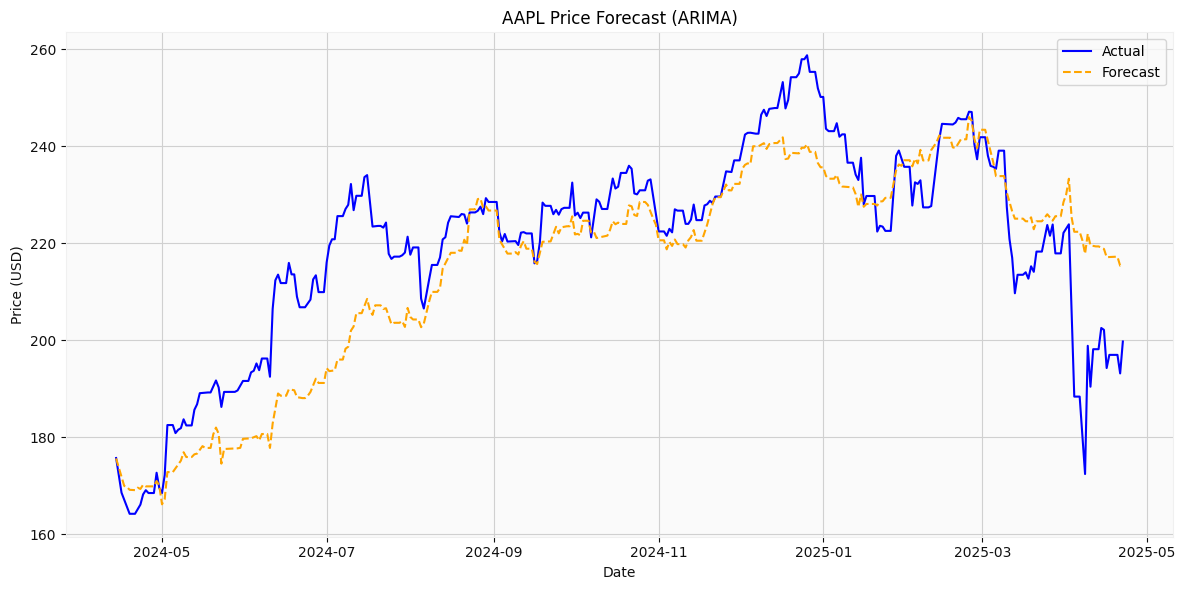


ARIMA predicted price for next day: 200.43 (+0.35%)
    MAE: 9.2758
    RMSE: 12.1994
    MAPE: 4.3245



Training LSTM Model...(Model 2/3)
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step


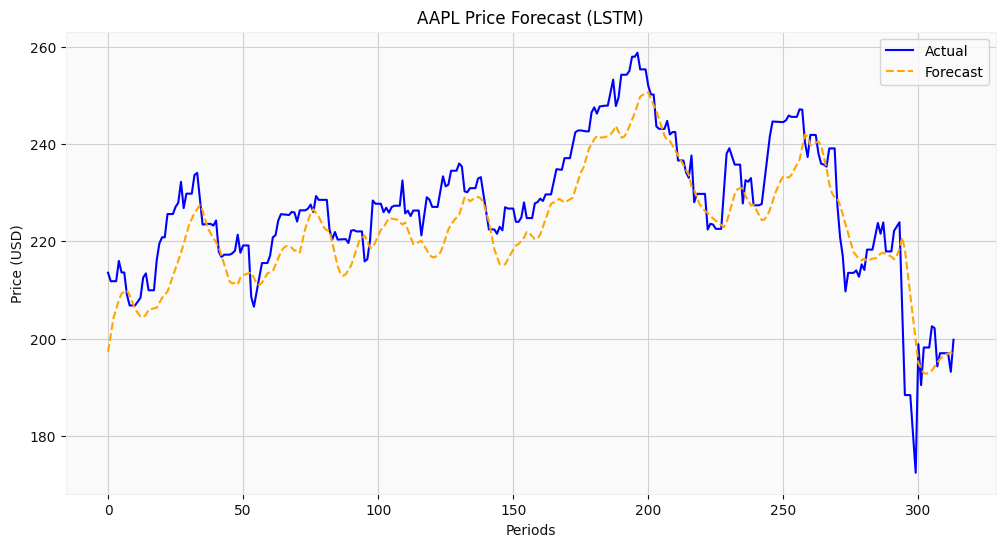


LSTM predicted price for next day: 196.62 (-1.56%)
    MAE: 6.0052
    RMSE: 7.5347
    MAPE: 2.6636



Training Prophet Model...(Model 3/3)


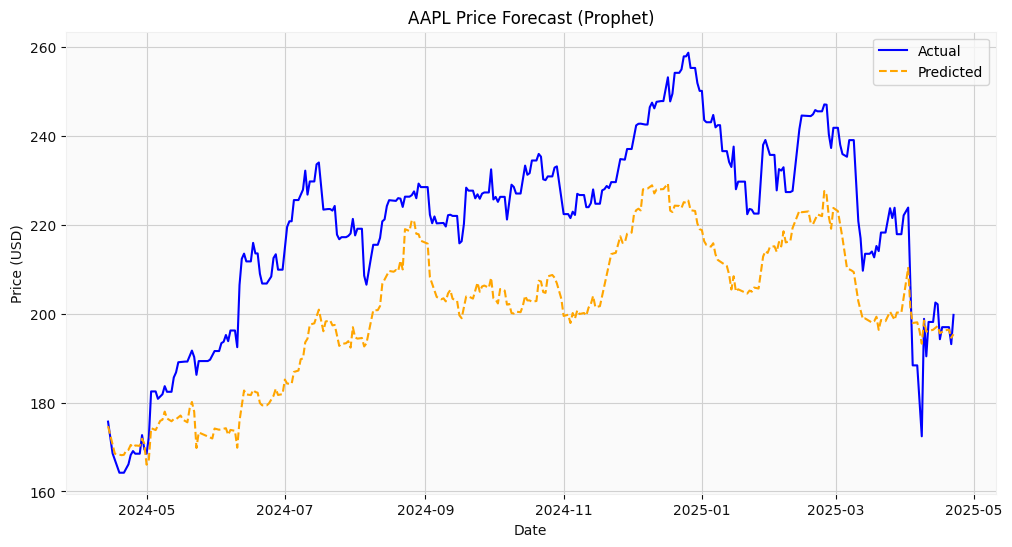


Prophet predicted price for next day: 195.39 (-2.18%)
    MAE: 19.6042
    RMSE: 21.4297
    MAPE: nan



Model Summaries:
ARIMA MAE: 9.2758, RMSE: 12.1994, MAPE: 4.3245, predicted price of 200.43 (+0.35%)
LSTM MAE: 6.0052, RMSE: 7.5347, MAPE: 2.6636, predicted price of 196.62 (-1.56%)
Prophet MAE: 19.6042, RMSE: 21.4297, MAPE: nan, predicted price of 195.39 (-2.18%)


In [ ]:
stock_analysis('AAPL', ma_window = 50)

#### Call the function for Amazon (AMZN), skipping stock preview

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed



AMZN data from 2020-01-01 to 2025-04-23 collected successfully



This graph shows the stock closing price over time, along with the moving average (period chosen with ma_period variable),
    upper and lower Bollinger Bands (moving average plus/minus 2*standard deviation of closing price), and the Relative Strength
    Index (RSI). An RSI of 70 or more typically means the stock is being over bought. A value of 30 or less typically means the
    stock is being over-sold



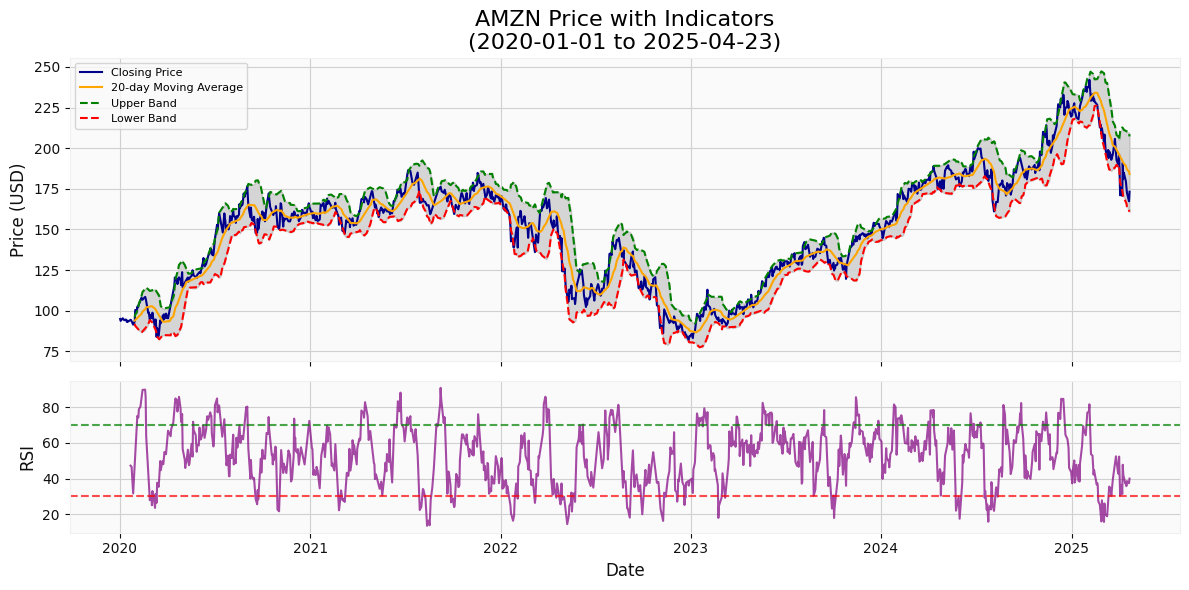




Training ARIMA Model...(Model 1/3)


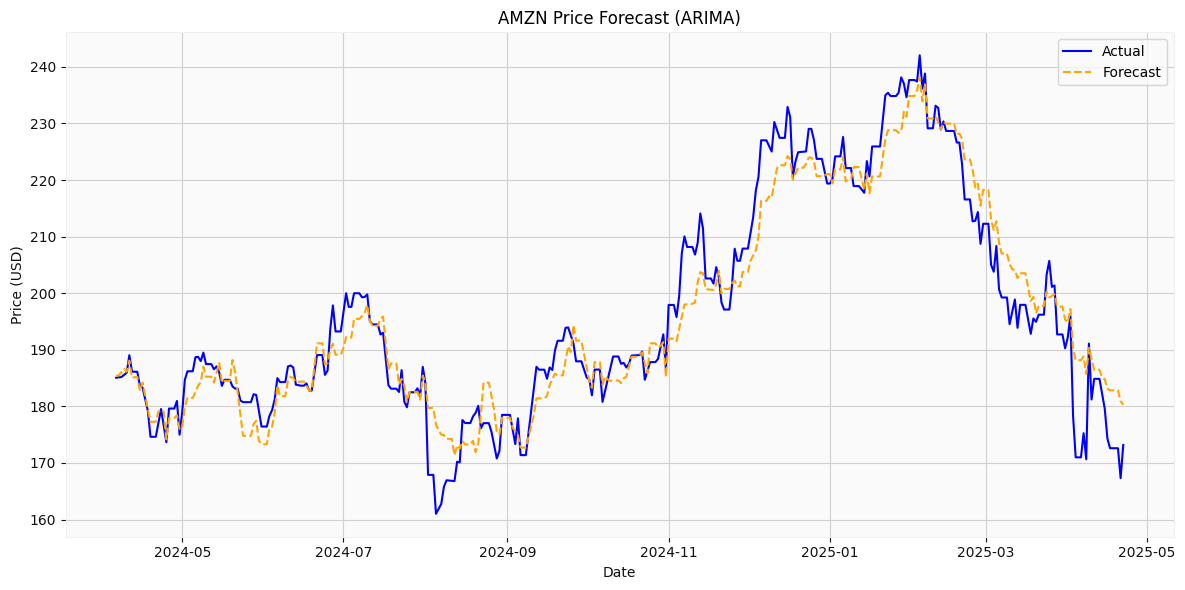


ARIMA predicted price for next day: 172.96 (-0.13%)
    MAE: 4.0275
    RMSE: 5.2013
    MAPE: 2.0760



Training LSTM Model...(Model 2/3)
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step 


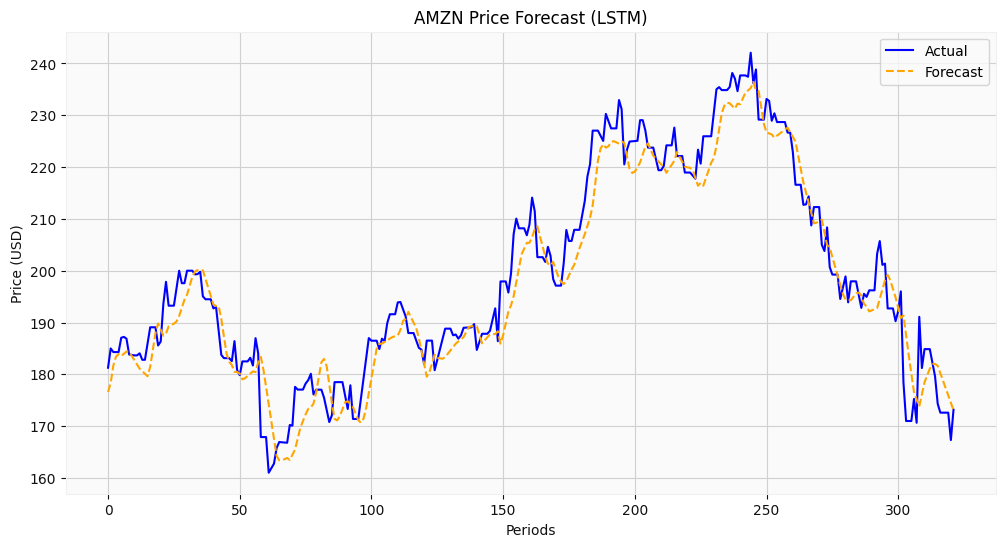


LSTM predicted price for next day: 172.41 (-0.45%)
    MAE: 4.1761
    RMSE: 5.2679
    MAPE: 2.1296



Training Prophet Model...(Model 3/3)


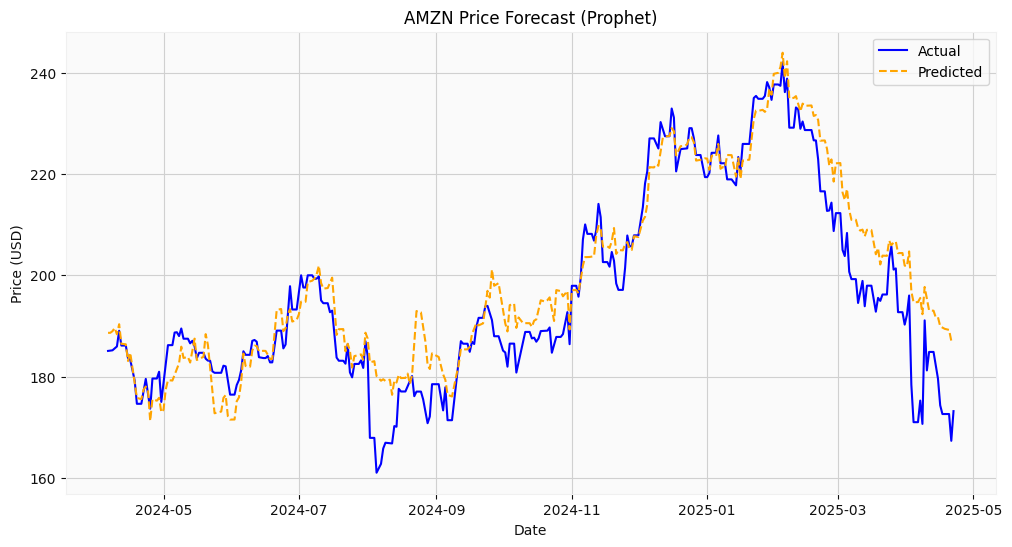


Prophet predicted price for next day: 186.84 (+7.89%)
    MAE: 5.2833
    RMSE: 7.0537
    MAPE: nan



Model Summaries:
ARIMA MAE: 4.0275, RMSE: 5.2013, MAPE: 2.0760, predicted price of 172.96 (-0.13%)
LSTM MAE: 4.1761, RMSE: 5.2679, MAPE: 2.1296, predicted price of 172.41 (-0.45%)
Prophet MAE: 5.2833, RMSE: 7.0537, MAPE: nan, predicted price of 186.84 (+7.89%)


In [ ]:
stock_analysis('AMZN', stock_preview = False)

### Next steps to improve the function

#### Modularization
- separating the large function into smaller functions will be helpful for future edits, and will allow the user more customizability

#### Incorporating sentiment analysis
- read in financial headlines and articles to ge the professional opinions on the state of the market

#### Changing the time period for prediction
- give the user the ability to chose time period for analysis (day, week, month) for longer projections

#### Model Parameter Optimization
- using grid search or cross validation to improve each model's accuracy at the cost of performance

**Overall, this function is a great tool for short-term stock market predictions of a single stock, and can be used by anyone.**